Title: SEM_Old.ipynb

Purpose: 

Author: Onno Nennecke on 28.02.2025 Modified: 06.03.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load cdo package for regridding
from cdo import Cdo
cdo = Cdo()


In [2]:
import wind_model_func
import solar_model_func
import demand

In [3]:
# Load wind height data
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')

In [4]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_power.nc')
grid_offshore = grid_offshore['wind_off_cap']
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_power.nc')
grid_onshore = grid_onshore['wind_on_cap']
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_power.nc')
grid_solar = grid_solar['solar_cap']

In [5]:
sfcWind = 0
rsds = 0
tas = 0
tas_max = 0

In [6]:
# Load climate data
scenario = 'CESM2' 
run = 'r1i1p1f1' # r10i1p1f1  r11i1p1f1  r1i1p1f1  r2i1p1f1  r3i1p1f1  r4i1p1f1  r5i1p1f1  r6i1p1f1  r7i1p1f1  r8i1p1f1  r9i1p1f1

# create list of variables
variables = ['sfcWind', 'rsds', 'tas'] # Surface Wind Speed, Downward Short-Wave Radiation, Air Temperature, Maximum Air Temperature # , 'tas_max'

# Load data
for variable in variables:
    nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{scenario}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{scenario}_historical_{run}_gn_*')
    # select variable
    globals()[variable] = nc[variable] 
    # filter winter
    globals()[variable] = globals()[variable][np.isin(globals()[variable].time.dt.month, [10,11,12,1,2,3]),:,:]
    # select region
    globals()[variable] = globals()[variable].sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
    
if tas.units == 'K':
    tas.attrs['units']= '°C'
    tas = tas - 273.15

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), n

## Wind energy production

In [7]:
# Calculate power from wind speed

alpha_on = 1/7 # Roughness parameter onshore
alpha_off = 0.11 # Roughness parameter offshore
ref_height = 10 # Height of wind data
v_cutin = 3.5 # Minimum wind speed to start producing power
v_cutout = 25 # Maximum wind speed to produce power
v_rated = 13 # Wind speed at which the turbine produces maximum power
# hub_height_on = 80 # Approximation: Onshore 80 m --> Bad Approximation
hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
# hub_height_off = 120 # Approximation: Offshore 120 m --> Bad Approximation
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [8]:
wepot_off = wind_model_func.compute_wind_energy_potential(sfcWind, grid_offsh_hub_height, alpha_off, ref_height)
wepot_on = wind_model_func.compute_wind_energy_potential(sfcWind, grid_onsh_hub_height, alpha_on, ref_height)

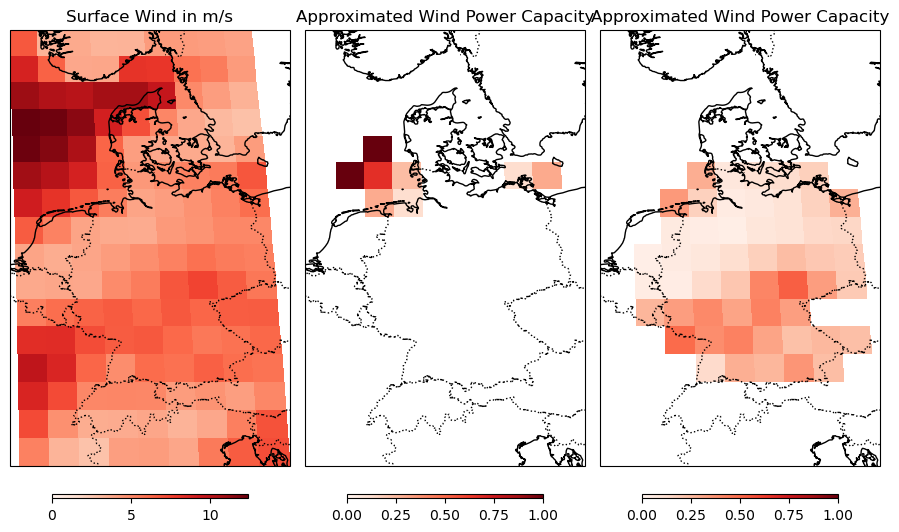

In [21]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = sfcWind.lon.values - (sfcWind.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = sfcWind.lat.values - (sfcWind.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 200 # 24507

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = sfcWind.isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()


In [9]:
weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

## Solar energy production

In [10]:
sepot = solar_model_func.compute_solar_energy_potential(rsds, tas, tas, sfcWind)

In [11]:
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

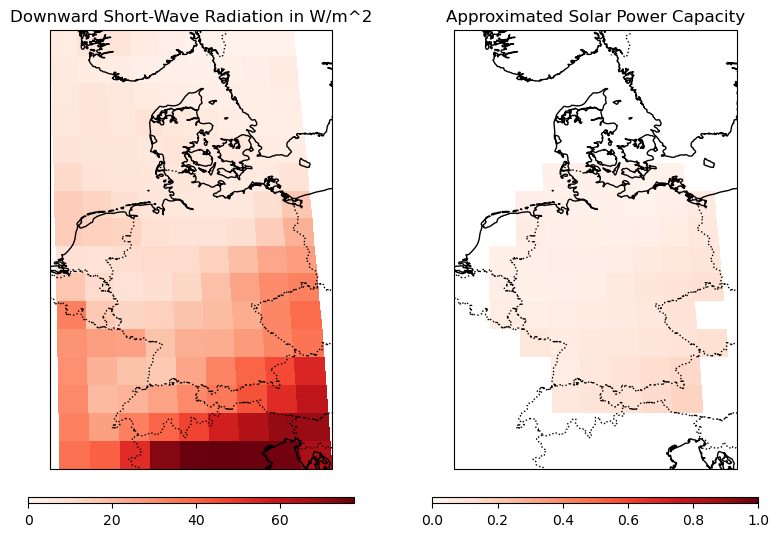

In [17]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity

# '''
lon_edges = rsds.lon.values - (rsds.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = rsds.lat.values - (rsds.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 10000# 29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = rsds.isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

In [12]:
seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

## Demand

In [13]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_regrid_weights.nc')

In [14]:
# Calculate weighted sum

weighted_temp_list = []
for y in np.unique(tas["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (tas.sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
 

In [27]:
ds_weighted_temp

<xarray.Dataset> Size: 721kB
Dimensions:  (time: 30031)
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
    country  float64 8B 9.0
    period   <U7 28B 'weekday'
Data variables:
    temp     (time) float64 240kB dask.array<chunksize=(1,), meta=np.ndarray>
    demand   (time) float64 240kB dask.array<chunksize=(1,), meta=np.ndarray>

In [15]:
# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/demand_fit_values.nc')

# Calculate demand
demand_ds = demand.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'weekday'))

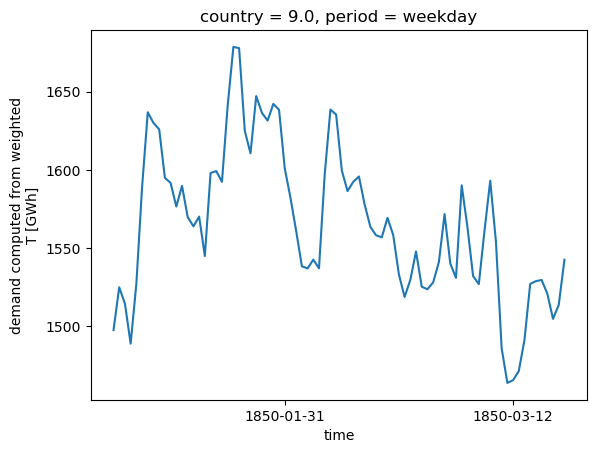

In [31]:
demand_ds['demand'][0:80].plot()

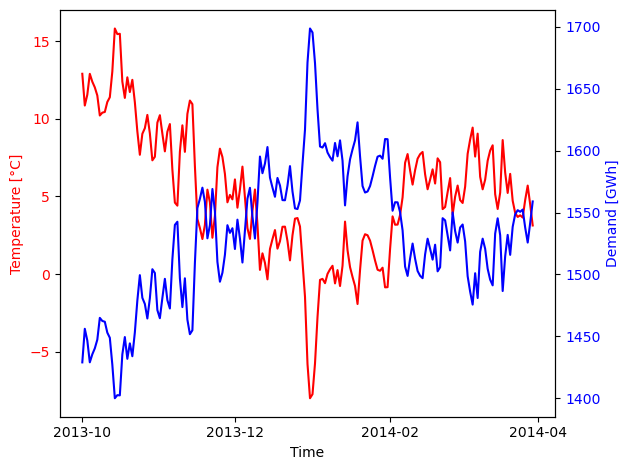

In [23]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 191 + 365 * 81
b = 7 + 365 * 82

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

## Combination

1. Idea: Calculate Grids with total energy production
2. Idea: Calculate a timeseries for each energy production

In [19]:
weprod_off

<xarray.Dataset> Size: 35MB
Dimensions:        (lat: 16, lon: 9, time: 30031)
Coordinates:
  * lat            (lat) float64 128B 45.71 46.65 47.59 ... 57.96 58.9 59.84
  * lon            (lon) float64 72B 5.0 6.25 7.5 8.75 ... 11.25 12.5 13.75 15.0
    crs            int64 8B 4326
  * time           (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:...
Data variables:
    wind_off_prod  (time, lat, lon) float64 35MB dask.array<chunksize=(1, 16, 9), meta=np.ndarray>
Attributes:
    units:       MWh d**-1
    short_name:  wind
    long_name:   wind energy production

In [20]:
weprod_on


<xarray.Dataset> Size: 35MB
Dimensions:       (lat: 16, lon: 9, time: 30031)
Coordinates:
  * lat           (lat) float64 128B 45.71 46.65 47.59 ... 57.96 58.9 59.84
  * lon           (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
    crs           int64 8B 4326
  * time          (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:0...
Data variables:
    wind_on_prod  (time, lat, lon) float64 35MB dask.array<chunksize=(1, 16, 9), meta=np.ndarray>
Attributes:
    units:       MWh d**-1
    short_name:  wind
    long_name:   wind energy production

In [26]:
seprod


<xarray.DataArray (time: 30031, lat: 16, lon: 9)> Size: 35MB
dask.array<mul, shape=(30031, 16, 9), dtype=float64, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
    crs      int64 8B 4326
Attributes:
    units:       MWh d**-1
    short_name:  solar
    long_name:   solar energy production

In [22]:
demand_ds

<xarray.Dataset> Size: 721kB
Dimensions:  (time: 30031)
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
    country  float64 8B 9.0
    period   <U7 28B 'weekday'
Data variables:
    temp     (time) float64 240kB dask.array<chunksize=(1,), meta=np.ndarray>
    demand   (time) float64 240kB dask.array<chunksize=(1,), meta=np.ndarray>